# Cluster Interpretation

This notebook interprets the output of the clustering pipeline (`train.py`) by:

1. **Loading** `Original.csv` — the inverse-scaled dataset with cluster labels attached by `inverse.py`
2. **Summarising** each cluster's mean feature values
3. **Visualising** cluster separation along the two most discriminating axes (CPU usage vs. download speed)
4. **Interpreting** cluster semantics and validating clustering quality

**Expected input:** `../data/result/Original.csv`  
**Cluster labels:** 0 = Low Activity · 1 = High Computational · 2 = Network-Intensive

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Used for the cluster scatter plot


## Load Dataset

Load `Original.csv`, which contains the full feature set at original scale with a
`Target` column holding the cluster assignment (0, 1, or 2) produced by the
PCA + KMeans pipeline.

In [2]:
# Load the labelled, inverse-scaled dataset output by inverse.py
df = pd.read_csv('../data/result/Original.csv')
df.head()


,timestamp,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,2026-03-09 00:18:05,60.0,63.0,36.8,-223.0,0.000000,0.000000,0
1,2026-03-09 00:18:13,60.0,67.0,36.8,-417.0,0.000000,0.000000,1
2,2026-03-09 00:18:17,65.0,67.0,36.4,-436.0,0.394765,0.768830,1
3,2026-03-09 00:18:21,52.0,67.0,36.4,-320.0,0.401153,0.540071,0
4,2026-03-09 00:18:25,56.0,65.0,36.4,-324.0,0.000000,0.000000,0


## Cluster Summary

Compute the per-cluster mean for every feature (excluding `timestamp`).
This table forms the quantitative basis for the cluster interpretation below.

In [3]:
# Group by cluster label and compute column-wise means
cluster_analysis = df.drop(columns=['timestamp']).groupby('Target').agg(['mean'])

# Flatten the MultiIndex columns produced by agg(['mean']) for easier reading
df_analysis = cluster_analysis.reset_index()
df_analysis.head()


,Target,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps
,,mean,mean,mean,mean,mean,mean
0,0,38.254239,72.698765,33.330679,-192.421673,1.065322,3.283031
1,1,56.184288,77.563908,35.020656,-356.063329,1.397557,7.127073
2,2,49.544304,74.873589,33.906740,-301.599213,7.079933,60.533346


### Cluster Scatter Plot

Plot each sample coloured by cluster label, using **CPU usage** and **download speed**
as the two axes — these are the features that most clearly separate the three clusters.
Black `×` markers show the per-cluster centroid computed from the original-scale data.

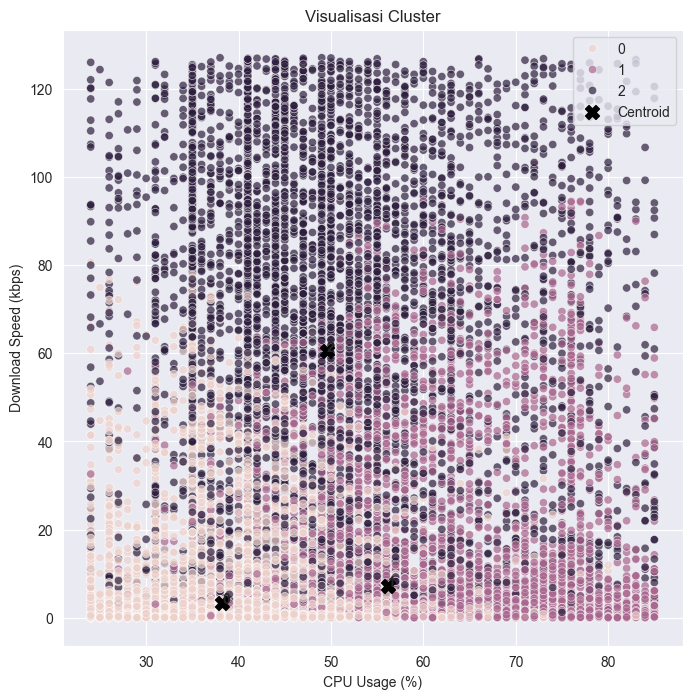

In [4]:
plt.figure(figsize=(8, 8))

# Compute centroids as the mean of each cluster along the two chosen axes
centroids = df.groupby('Target')[['cpu_usage', 'download_speed_kbps']].mean()

# Draw one point per sample, coloured by cluster
sns.scatterplot(
    data=df,
    x='cpu_usage',
    y='download_speed_kbps',
    hue='Target',
    alpha=0.7
)

# Annotate each centroid with its cluster label
for label, row in centroids.iterrows():
    plt.text(
        row['cpu_usage'],
        row['download_speed_kbps'],
        label,
        fontsize=10,
        weight='bold'
    )

# Overlay centroid markers
plt.scatter(
    centroids['cpu_usage'],
    centroids['download_speed_kbps'],
    c='black',
    s=100,
    marker='X',
    label='Centroid'
)

plt.title('Cluster Visualisation — CPU Usage vs. Download Speed')
plt.xlabel('CPU Usage (%)')
plt.ylabel('Download Speed (kbps)')
plt.legend()
plt.show()


## Interpretation
### Introduction
Based on the result of the K-Means clustering process with PCA transformation, the model produce three clusters (K = 3) representing different device workload conditions. The number of cluster is based on the Elbow Method analysis, which indicated the optimal number of cluster is 3 clusters, this the number of cluster pocked is 3 Clusters.
- CPU Usage (%)
- Memory Usage (%)
- Temperature (°C)
- Battery Current (mA)
- Upload Speed (kbps)
- Download Speed (kbps)

### Cluster Characteristic
#### Label 0 (Low Activity State)
Cluster 0 represents periods of minimal device activity characterized by:

- Lowest CPU and temperature → minimal processing
- Very low network throughput → little to no user interaction
- Lowest battery drain → energy-efficient state

This condition typically occurs when the device is idle or running only background services.

#### Label 1 (High Computational Workload)
Cluster 1 represents CPU/memory-heavy workloads, not network-heavy ones.

- Highest CPU + memory → active processing
- Highest temperature → sustained compute load
- Low–moderate network → not bandwidth-driven
- Highest battery drain overall

This condition typically corresponds to heavy workload such as gaming or heavy app usage.

#### Label 2 (Network-Intensive Condition)
Cluster 2 represents periods where network traffic dominates system behavior, characterized by:

- Extremely high download throughput → dominant feature
- Moderate CPU usage → processing + network handling
- Battery drain high, but less than Cluster 1

This condition commonly occurs during activities such as video streaming, large file downloads, cloud synchronization, or continuous online media consumption (e.g., YouTube or TikTok).

### Clustering Validation
To evaluate the clustering quality, the following validation metrics were used:

- Silhouette Score: 0.453
- Davies Bouldin Index: 0.784
- Calinski Harabasz Score: 32023.033

**Interpreting the scores:**
- **Silhouette Score (0.453)** — ranges from -1 to 1; values above 0.4 indicate reasonably well-separated clusters with some overlap, which is acceptable for real-world sensor data.
- **Davies–Bouldin Index (0.784)** — lower is better; values below 1.0 indicate clusters are compact and well-separated relative to their inter-cluster distance.
- **Calinski–Harabasz Score (32,023)** — higher is better; the high value confirms dense, well-defined clusters with large between-cluster dispersion relative to within-cluster variance.

Overall, the three metrics consistently indicate **good clustering quality** for a 3-cluster solution on this dataset.